In [2]:
# ==========================================================
# LIBRERÍAS
# ==========================================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
import os
import configparser

config = configparser.ConfigParser()

current_dir = os.getcwd()

config_path = os.path.join(
    current_dir,
    "..",
    "config",
    "settings.ini"
)

print(config_path)

config.read(config_path)

print(config.sections())

c:\Users\Florencia\Documents\Materia Proyecto BBDD\Scripts\05_machine_learning\..\config\settings.ini
[]


In [4]:
# ==========================================================
# CONFIGURACIÓN Y CONEXIÓN A SNOWFLAKE
# ==========================================================

import configparser
import snowflake.connector

config = configparser.ConfigParser()

config.read(
    r"C:\Users\Florencia\Documents\Materia Proyecto BBDD\Scripts\04_etl_pipeline\VitaHealth_dw\config\settings.ini"
)

conn = snowflake.connector.connect(

    user=config["snowflake"]["user"],
    password=config["snowflake"]["password"],
    account=config["snowflake"]["account"],
    warehouse=config["snowflake"]["warehouse"],
    database=config["snowflake"]["database"],
    schema=config["snowflake"]["schema"],
    role=config["snowflake"]["role"]

)

print("✅ Conexión a Snowflake establecida correctamente.")

✅ Conexión a Snowflake establecida correctamente.


In [5]:
# ==========================================================
# CONSTRUCCIÓN DEL DATASET PARA MACHINE LEARNING
# ==========================================================

query = """

SELECT

    -- ===========================
    -- IDENTIFICADORES
    -- ===========================

    f.EXPERIENCE_KEY,

    -- ===========================
    -- PACIENTE
    -- ===========================

    p.EDAD,
    p.SEXO,
    p.ZONA,
    p.ANTIGUEDAD_MESES,

    -- ===========================
    -- PLAN
    -- ===========================

    pl.NOMBRE_PLAN,
    pl.CATEGORIA,
    pl.SEGMENTO,
    pl.VALOR_PLAN,
    pl.COPAGO,

    -- ===========================
    -- SERVICIO
    -- ===========================

    s.NOMBRE_SERVICIO,

    -- ===========================
    -- CENTRO MÉDICO
    -- ===========================

    c.NOMBRE_CENTRO,

    -- ===========================
    -- EXPERIENCIA
    -- ===========================

    f.TIEMPO_ESPERA,
    f.CANCELADO,
    f.ASISTIO,
    f.TIENE_RECLAMO,
    f.DIAS_RESOLUCION,

    -- ===========================
    -- SATISFACCIÓN
    -- ===========================

    f.PUNTUACION_NPS,
    f.CSAT

FROM FACT_CUSTOMER_EXPERIENCE f

INNER JOIN DIM_PATIENT p
    ON f.PATIENT_KEY = p.PATIENT_KEY

INNER JOIN DIM_PLAN pl
    ON f.PLAN_KEY = pl.PLAN_KEY

INNER JOIN DIM_SERVICE s
    ON f.SERVICE_KEY = s.SERVICE_KEY

INNER JOIN DIM_MEDICAL_CENTER c
    ON f.CENTER_KEY = c.CENTER_KEY

"""

df = pd.read_sql(query, conn)

print(f"Registros: {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")

df.head()

Registros: 102,579
Columnas : 19


,EXPERIENCE_KEY,EDAD,SEXO,ZONA,ANTIGUEDAD_MESES,NOMBRE_PLAN,CATEGORIA,SEGMENTO,VALOR_PLAN,COPAGO,NOMBRE_SERVICIO,NOMBRE_CENTRO,TIEMPO_ESPERA,CANCELADO,ASISTIO,TIENE_RECLAMO,DIAS_RESOLUCION,PUNTUACION_NPS,CSAT
0,1,55,Femenino,Centro,36,Plus,Individual,Intermedio,70000.0,2500.0,Guardia,Instituto Médico Central,93,False,True,False,0,8,9
1,2,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Guardia,Clínica del Valle,68,False,True,False,0,9,9
2,3,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Consultorio Clínico,Centro Médico Norte,22,False,True,False,0,9,9
3,4,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Guardia,Clínica del Valle,92,False,True,False,0,9,9
4,5,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Consultorio Clínico,Instituto Médico Central,33,False,True,False,0,9,9


In [6]:
# ==========================================================
# CREACIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

# Un paciente es detractor cuando su NPS es menor o igual a 6

df["ES_DETRACTOR"] = (
    df["PUNTUACION_NPS"] <= 6
).astype(int)

df["ES_DETRACTOR"].value_counts()

ES_DETRACTOR
0    74886
1    27693
Name: count, dtype: int64

In [7]:
# ==========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

display(
    df["ES_DETRACTOR"]
    .value_counts()
)

display(
    round(
        df["ES_DETRACTOR"]
        .value_counts(normalize=True) * 100,
        2
    )
)

ES_DETRACTOR
0    74886
1    27693
Name: count, dtype: int64

ES_DETRACTOR
0    73.0
1    27.0
Name: proportion, dtype: float64

In [8]:
# ==========================================================
# ELIMINACIÓN DE VARIABLES CON DATA LEAKAGE
# ==========================================================

df_modelo = df.drop(
    columns=[
        "EXPERIENCE_KEY",
        "PUNTUACION_NPS",
        "CSAT"
    ]
)

df_modelo.head()

,EDAD,SEXO,ZONA,ANTIGUEDAD_MESES,NOMBRE_PLAN,CATEGORIA,SEGMENTO,VALOR_PLAN,COPAGO,NOMBRE_SERVICIO,NOMBRE_CENTRO,TIEMPO_ESPERA,CANCELADO,ASISTIO,TIENE_RECLAMO,DIAS_RESOLUCION,ES_DETRACTOR
0,55,Femenino,Centro,36,Plus,Individual,Intermedio,70000.0,2500.0,Guardia,Instituto Médico Central,93,False,True,False,0,0
1,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Guardia,Clínica del Valle,68,False,True,False,0,0
2,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Consultorio Clínico,Centro Médico Norte,22,False,True,False,0,0
3,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Guardia,Clínica del Valle,92,False,True,False,0,0
4,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Consultorio Clínico,Instituto Médico Central,33,False,True,False,0,0


Se eliminan las variables PUNTUACION_NPS y CSAT debido a que la variable objetivo (ES_DETRACTOR) se deriva directamente del NPS y el CSAT presenta una correlación muy elevada con dicha métrica. Su inclusión produciría data leakage, generando un modelo con un rendimiento artificialmente elevado.

In [9]:
# ==========================================================
# VARIABLES PREDICTORAS Y OBJETIVO
# ==========================================================

X = df_modelo.drop(columns="ES_DETRACTOR")

y = df_modelo["ES_DETRACTOR"]

print(X.shape)
print(y.shape)

(102579, 16)
(102579,)


In [10]:
# ==========================================================
# LIBRERÍAS PARA MACHINE LEARNING
# ==========================================================

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

In [11]:
# ==========================================================
# VARIABLES NUMÉRICAS Y CATEGÓRICAS
# ==========================================================

numericas = X.select_dtypes(
    include=["int64","float64","bool"]
).columns.tolist()

categoricas = X.select_dtypes(
    include="object"
).columns.tolist()

print(numericas)

print(categoricas)

['EDAD', 'ANTIGUEDAD_MESES', 'VALOR_PLAN', 'COPAGO', 'TIEMPO_ESPERA', 'CANCELADO', 'ASISTIO', 'TIENE_RECLAMO', 'DIAS_RESOLUCION']
['SEXO', 'ZONA', 'NOMBRE_PLAN', 'CATEGORIA', 'SEGMENTO', 'NOMBRE_SERVICIO', 'NOMBRE_CENTRO']


In [12]:
# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")

Train: (82063, 16)
Test : (20516, 16)


In [13]:
# ==========================================================
# PREPROCESAMIENTO
# ==========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [14]:
# Pipeline para variables numéricas

numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median"))

    ]

)

# Pipeline para variables categóricas

categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("onehot", OneHotEncoder(handle_unknown="ignore"))

    ]

)

# Preprocesador completo

preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numericas),

        ("cat", categorical_transformer, categoricas)

    ]

)

In [15]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

In [16]:
# ==========================================================
# PIPELINE RANDOM FOREST
# ==========================================================

rf_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", RandomForestClassifier(

            n_estimators=300,

            min_samples_split=10,

            min_samples_leaf=5,

            class_weight="balanced",

            random_state=42,

            n_jobs=-1

        ))
    ]

)

# ==========================================================
# AJUSTE DE HIPERPARÁMETROS
# ==========================================================

Con el objetivo de mejorar la capacidad predictiva del modelo y reducir el sesgo hacia la clase mayoritaria, se realizó un ajuste manual de los principales hiperparámetros de Random Forest.

Los cambios implementados fueron:

- **n_estimators = 300:** aumento de la cantidad de árboles para obtener un modelo más robusto y estable.
- **max_depth = 15:** limitación de la profundidad máxima de los árboles para reducir el sobreajuste.
- **min_samples_split = 10:** incremento del número mínimo de muestras necesarias para dividir un nodo, favoreciendo árboles menos complejos.
- **min_samples_leaf = 5:** exigencia de un mínimo de observaciones por hoja para mejorar la generalización del modelo.
- **class_weight = "balanced":** compensación automática del desbalance existente entre pacientes detractores y no detractores, otorgando mayor peso a la clase minoritaria.
- **random_state = 42:** fijación de la semilla para garantizar la reproducibilidad de los resultados.
- **n_jobs = -1:** utilización de todos los núcleos disponibles del procesador para optimizar el tiempo de entrenamiento.

Estos ajustes fueron realizados de forma iterativa, evaluando su impacto sobre las métricas de desempeño, especialmente **Recall** y **F1 Score**, debido a que el objetivo principal del proyecto consiste en identificar correctamente a los pacientes con riesgo de convertirse en detractores.

In [17]:
# ==========================================================
# ENTRENAMIENTO
# ==========================================================

rf_pipeline.fit(

    X_train,

    y_train

)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [18]:
# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = rf_pipeline.predict(X_test)

y_prob = rf_pipeline.predict_proba(X_test)[:,1]

In [19]:
# ==========================================================
# MÉTRICAS
# ==========================================================

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")

print(f"Precision: {precision_score(y_test, y_pred):.3f}")

print(f"Recall   : {recall_score(y_test, y_pred):.3f}")

print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")

print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.3f}")

Accuracy : 0.682
Precision: 0.406
Recall   : 0.378
F1 Score : 0.391
ROC AUC  : 0.631


In [20]:
# ==========================================================
# REPORTE
# ==========================================================

print(classification_report(

    y_test,

    y_pred

))

              precision    recall  f1-score   support

           0       0.78      0.79      0.79     14977
           1       0.41      0.38      0.39      5539

    accuracy                           0.68     20516
   macro avg       0.59      0.59      0.59     20516
weighted avg       0.68      0.68      0.68     20516



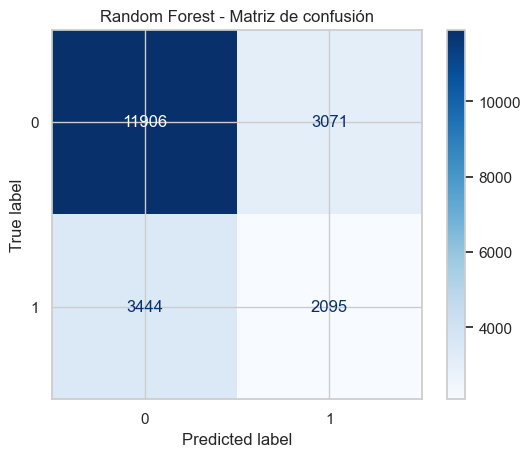

In [21]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred,

    cmap="Blues"

)

plt.title("Random Forest - Matriz de confusión")

plt.show()

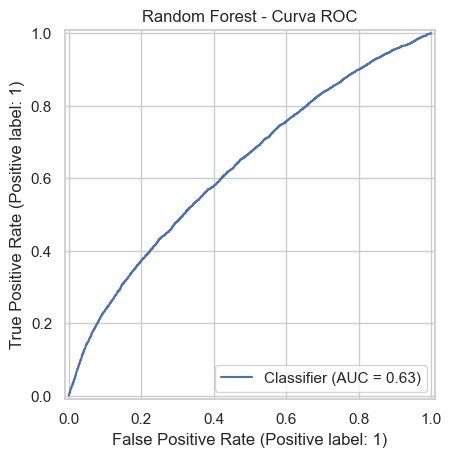

In [22]:
# ==========================================================
# CURVA ROC
# ==========================================================

RocCurveDisplay.from_predictions(

    y_test,

    y_prob

)

plt.title("Random Forest - Curva ROC")

plt.show()

In [23]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

# Obtener el modelo entrenado
modelo_rf = rf_pipeline.named_steps["model"]

# Obtener los nombres de las variables luego del OneHotEncoder
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Crear DataFrame con las importancias
importancias = pd.DataFrame({

    "Variable": feature_names,

    "Importancia": modelo_rf.feature_importances_

})

importancias = importancias.sort_values(

    by="Importancia",

    ascending=False

)

display(importancias.head(20))

,Variable,Importancia
1,num__ANTIGUEDAD_MESES,0.221701
0,num__EDAD,0.217630
4,num__TIEMPO_ESPERA,0.185994
8,num__DIAS_RESOLUCION,0.063911
7,num__TIENE_RECLAMO,0.027848
12,cat__ZONA_Centro,0.018033
13,cat__ZONA_Norte,0.017736
15,cat__ZONA_Sur,0.017573
9,cat__SEXO_Femenino,0.017266
10,cat__SEXO_Masculino,0.017178


# XGBoost

In [24]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# ==========================================================
# XGBOOST
# ==========================================================

from xgboost import XGBClassifier

print("XGBoost instalado correctamente")

XGBoost instalado correctamente


In [26]:
import sys

print(sys.executable)

c:\Users\Florencia\AppData\Local\Programs\Python\Python310\python.exe


In [27]:
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale = negativos / positivos

print(f"Scale Pos Weight: {scale:.2f}")

Scale Pos Weight: 2.70


In [28]:
# ==========================================================
# MODELO XGBOOST
# ==========================================================

modelo_xgb = XGBClassifier(

    random_state=42,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    gamma=1,

    scale_pos_weight=scale,

    eval_metric="logloss"

)

# ==========================================================
# AJUSTE DE HIPERPARÁMETROS
# ==========================================================

## XGBoost

Se realizaron los siguientes ajustes:

- **n_estimators = 300:** incremento de la cantidad de árboles.
- **learning_rate = 0.05:** reducción de la tasa de aprendizaje para mejorar la estabilidad del modelo.
- **max_depth = 6:** control de la complejidad de los árboles.
- **min_child_weight = 3:** incremento del mínimo de observaciones necesarias para generar nuevas particiones.
- **subsample = 0.8:** utilización del 80% de las observaciones en cada árbol.
- **colsample_bytree = 0.8:** utilización del 80% de las variables en cada árbol.
- **gamma = 1:** incorporación de una ganancia mínima antes de realizar nuevas divisiones.
- **scale_pos_weight = 2.70:** compensación del desbalance entre clases para mejorar la detección de pacientes detractores.

In [29]:
# ==========================================================
# PIPELINE XGBOOST
# ==========================================================

xgb_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", modelo_xgb)

    ]

)

In [30]:
# ==========================================================
# ENTRENAMIENTO
# ==========================================================

xgb_pipeline.fit(

    X_train,

    y_train

)

print("Modelo XGBoost entrenado correctamente.")

Modelo XGBoost entrenado correctamente.


In [31]:
# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

In [32]:
# ==========================================================
# MÉTRICAS
# ==========================================================

print(f"Accuracy : {accuracy_score(y_test,y_pred_xgb):.3f}")

print(f"Precision: {precision_score(y_test,y_pred_xgb):.3f}")

print(f"Recall   : {recall_score(y_test,y_pred_xgb):.3f}")

print(f"F1 Score : {f1_score(y_test,y_pred_xgb):.3f}")

print(f"ROC AUC  : {roc_auc_score(y_test,y_prob_xgb):.3f}")

Accuracy : 0.662
Precision: 0.403
Recall   : 0.526
F1 Score : 0.456
ROC AUC  : 0.685


In [33]:
# ==========================================================
# REPORTE DE CLASIFICACIÓN
# ==========================================================

print(

    classification_report(

        y_test,

        y_pred_xgb

    )

)

              precision    recall  f1-score   support

           0       0.80      0.71      0.75     14977
           1       0.40      0.53      0.46      5539

    accuracy                           0.66     20516
   macro avg       0.60      0.62      0.61     20516
weighted avg       0.69      0.66      0.67     20516



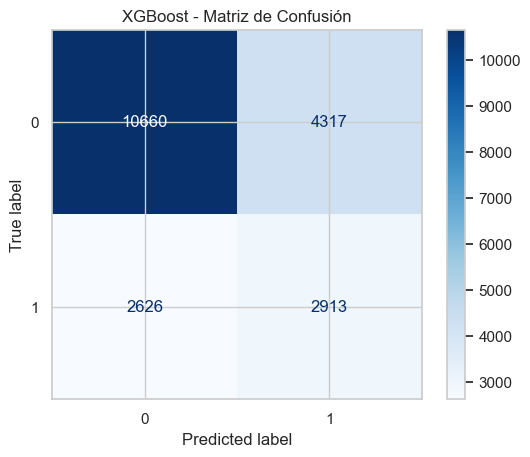

In [34]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_xgb,

    cmap="Blues"

)

plt.title("XGBoost - Matriz de Confusión")

plt.show()

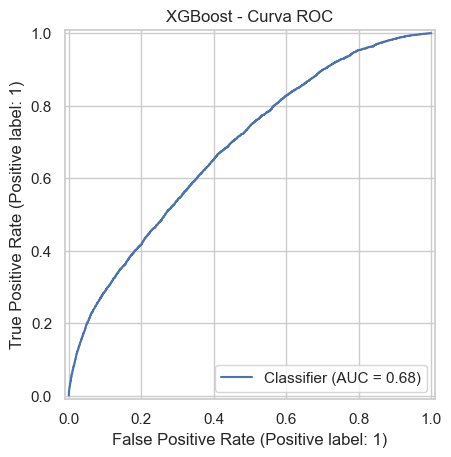

In [35]:
# ==========================================================
# CURVA ROC
# ==========================================================

RocCurveDisplay.from_predictions(

    y_test,

    y_prob_xgb

)

plt.title("XGBoost - Curva ROC")

plt.show()

In [36]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

modelo_xgb = xgb_pipeline.named_steps["model"]

feature_names = xgb_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias_xgb = pd.DataFrame({

    "Variable": feature_names,

    "Importancia": modelo_xgb.feature_importances_

})

importancias_xgb = (

    importancias_xgb

    .sort_values(

        by="Importancia",

        ascending=False

    )

)

display(importancias_xgb.head(20))

,Variable,Importancia
7,num__TIENE_RECLAMO,0.132563
29,cat__NOMBRE_SERVICIO_Guardia,0.061315
8,num__DIAS_RESOLUCION,0.048460
16,cat__NOMBRE_PLAN_Corporate,0.046765
3,num__COPAGO,0.036338
17,cat__NOMBRE_PLAN_Essential,0.032474
19,cat__NOMBRE_PLAN_Premium,0.032036
12,cat__ZONA_Centro,0.031394
1,num__ANTIGUEDAD_MESES,0.031254
0,num__EDAD,0.031153


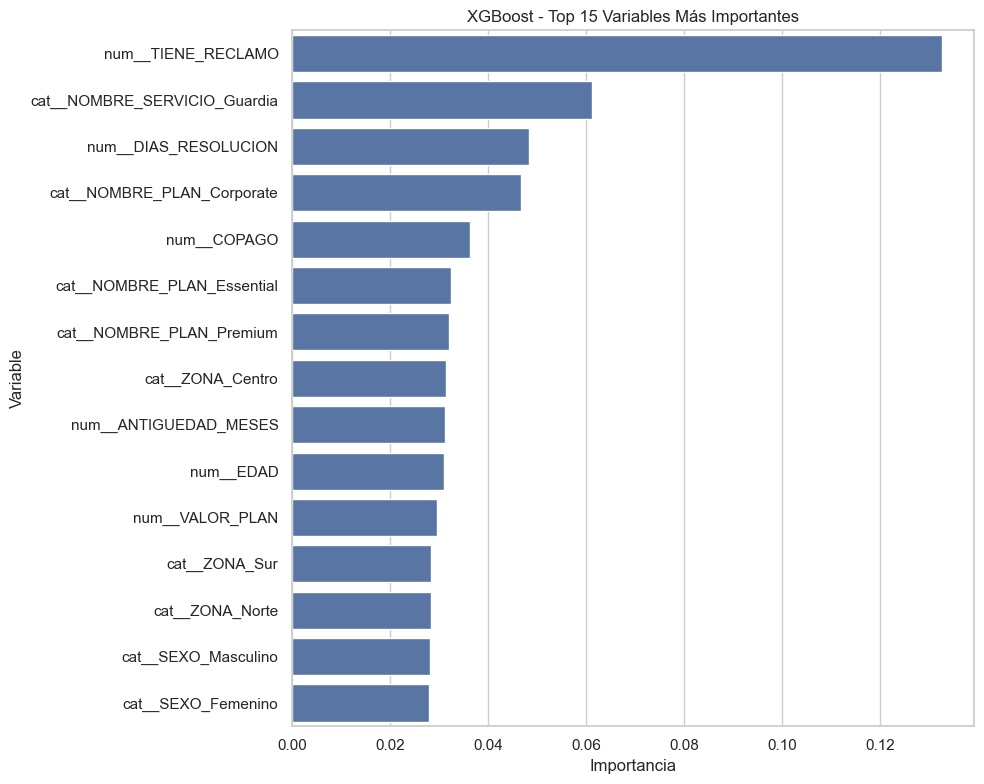

In [37]:
# ==========================================================
# TOP 15 VARIABLES MÁS IMPORTANTES
# ==========================================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=importancias_xgb.head(15),

    x="Importancia",

    y="Variable"

)

plt.title("XGBoost - Top 15 Variables Más Importantes")

plt.tight_layout()

plt.show()

| Tipo de variable     | Ejemplos                             | Importancia 
| -------------------- | ------------------------------------ | -----------   
| **Operativas**       | Reclamo, Días de resolución, Guardia | ⭐⭐⭐⭐⭐ 
| **Cobertura / Plan** | Plan, Copago, Valor del plan         | ⭐⭐⭐⭐    
| **Demográficas**     | Edad, Sexo, Antigüedad               | ⭐⭐⭐      
| **Geográficas**      | Zona                                 | ⭐⭐⭐      


El modelo muestra que las variables operativas relacionadas con la experiencia asistencial (reclamos, tiempos de resolución y tipo de servicio) poseen un mayor poder predictivo que las características demográficas del paciente. Esto sugiere que la probabilidad de que un paciente se convierta en detractor depende principalmente de cómo fue gestionada su experiencia de atención y no tanto de quién es el paciente.

# Comparación de modelos

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================
# Predicciones Random Forest
# ==========================

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# ==========================
# Predicciones XGBoost
# ==========================

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# ==========================
# Comparación
# ==========================

comparacion = pd.DataFrame({

    "Modelo": [
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]

})

display(comparacion.round(4))

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.6824,0.4055,0.3782,0.3914,0.631
1,XGBoost,0.6616,0.4029,0.5259,0.4563,0.685


In [39]:
# ===========================================
# 12. EXPORTACIÓN PARA POWER BI
# ===========================================

# Exportar comparación de modelos
comparacion.round(4).to_csv(
    "metricas_modelo.csv",
    sep=";",              # Separador compatible con Power BI en español
    decimal=",",          # Coma como separador decimal
    encoding="utf-8-sig", # Mantiene correctamente los acentos
    index=False
)

In [40]:
# ===========================================
# Exportar importancia de variables para Power BI
# ===========================================

importancias_export = importancias_xgb.copy()

# Convertir la importancia a porcentaje
importancias_export["Importancia"] = (
    importancias_export["Importancia"] * 100
).round(2)

# Exportar
importancias_export.to_csv(
    "importancia_variables.csv",
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
    index=False
)